In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import seaborn as sns
import matplotlib.pyplot as plt

### Feature engineering
For each column in cols, it adds:
- col_lag1, col_lag2: value from 1 and 2 days earlier.
- col_roll7, col_roll14: rolling mean over past 7/14 days (past-only, not using current day).
- col_diff1: day-to-day change (today - yesterday).

- It gives the model trend/history information, not just today’s raw value.

In [2]:
# -------------------------
# 1) Feature engineering
# -------------------------
def add_time_features(df: pd.DataFrame, cols, lags=(1,2), rolls=(7,14), diffs=(1,), slopes=(5,)):
    df = df.sort_values("date").copy()

    for col in cols:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

        # Past-only rolling means: shift first, then roll
        s = df[col].shift(1)
        for w in rolls:
            df[f"{col}_roll{w}"] = s.rolling(w, min_periods=max(3, w//3)).mean()

        for d in diffs:
            df[f"{col}_diff{d}"] = df[col].diff(d)

        # Rolling linear slope: positive = rising trend, negative = falling trend
        for w in slopes:
            df[f"{col}_slope{w}"] = s.rolling(w, min_periods=3).apply(
                lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
            )

    return df

In [3]:
# -------------------------
# 2) Read Data
# -------------------------
FILE_NAME = f"./data/garmin_data_180days/garmin_data_180days.csv"
df = pd.read_csv(FILE_NAME)

# basic shape + columns
print("Shape:", df.shape)
# print("\nColumns:")
# print(df.columns.tolist())

# dtypes + non-null counts
# print("\nInfo:")
# print(df.info())

# missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})

cols_to_keep = [c for c in df.columns if missing_pct[c] < 60]
df = df[cols_to_keep]

# missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})

print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(5))

# duplicates
print("\nDuplicate rows:", df.duplicated().sum())


# numeric summary
# print("\nNumeric summary:")
# print(df.describe(include=[ "number" ]).T)

# categorical/text/date-like summary
# print("\nNon-numeric summary:")
# print(df.describe(include=[ "object", "category", "bool" ]).T)

# optional: if you have a date column named 'date'
if "date" in df.columns:
    tmp = df.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    print("\nDate range:", tmp["date"].min(), "to", tmp["date"].max())
    print("Invalid dates:", tmp["date"].isna().sum())

Shape: (181, 51)

Missing values (top):
                     missing_count  missing_pct
awake_sleep_hr                  24        13.26
hrv_rmssd                        3         1.66
avg_sleep_stress                 3         1.66
lastnight_5min_high              3         1.66
deep_sleep_hr                    3         1.66

Duplicate rows: 0

Date range: 2025-10-22 00:00:00 to 2026-04-20 00:00:00
Invalid dates: 0


In [4]:
# -------------------------
# 3) Build dataset
# -------------------------
target = "cycle_phase"
BINARY_LUTEAL_TEST = False
FOLLICULAR_LUTEAL_MENSTRUAL_TEST = True

base_cols = [
    "date",
    "hrv_rmssd", "resting_hr", "avg_sleep_hr",
    "sleep_score", "total_sleep_hr", "deep_sleep_hr", "light_sleep_hr", "rem_sleep_hr", #"awake_sleep_hr",
    "avg_sleep_stress", "avg_sleep_respiration",
    "avgStressLevel", "maxStressLevel",
    "dailyTrainingLoadChronic", "dailyTrainingLoadAcute", "acwrPercent",
    "drained", "charged",
]

base_cols = list(dict.fromkeys(base_cols))

needed = base_cols + [target]
missing = [c for c in needed if c not in df.columns]
print("Missing columns:", missing)

# df must have: date + base_cols + target
df_model = df[needed].copy()
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
df_model = df_model.sort_values("date")

# Normalise label casing; merge legacy "fertile" and "ovulation" values
# (these are absent after re-downloading with the updated garmin_download.py)
df_model[target] = (
    df_model[target]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"ovulation": "luteal", "fertile": "luteal"})
)

print(df_model[target].value_counts(dropna=False))

print("Duplicate columns:", df_model.columns[df_model.columns.duplicated()].tolist())

df_model = add_time_features(
    df_model,
    cols=["hrv_rmssd","resting_hr","sleep_score","avgStressLevel","avg_sleep_hr","avg_sleep_respiration"],
    rolls=(7, 14, 21),
)

# Drop rows where label missing (keep feature NaNs for imputer)
df_model = df_model.dropna(subset=[target]).reset_index(drop=True)

# missing values
missing_count = df_model.isna().sum().sort_values(ascending=False)
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print("Missing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(5))

# Features: keep only numeric columns (or define explicitly)
feature_cols = [c for c in df_model.columns if c not in ["date", target]]

X = df_model[feature_cols]

if BINARY_LUTEAL_TEST:
    # 1 = luteal, 0 = non-luteal (menstrual/follicular)
    y = (df_model[target] == "luteal").astype(int)
    target_label_names = {0: "rest", 1: "luteal"}
elif FOLLICULAR_LUTEAL_MENSTRUAL_TEST:
    y = df_model[target]
else:
    y = df_model[target]
    target_label_names = None

print("Target distribution:")
print(pd.Series(y).value_counts())

# -------------------------
# Time-based holdout split
# -------------------------
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


Missing columns: []
cycle_phase
luteal        89
follicular    57
menstrual     35
Name: count, dtype: int64
Duplicate columns: []
Missing values (top):
                              missing_count  missing_pct
hrv_rmssd_slope5                         20        11.05
avg_sleep_respiration_slope5             20        11.05
avg_sleep_hr_slope5                      20        11.05
sleep_score_slope5                       20        11.05
hrv_rmssd_diff1                           7         3.87
Target distribution:
cycle_phase
luteal        89
follicular    57
menstrual     35
Name: count, dtype: int64


In [5]:
Xn = X_train.select_dtypes(include=[np.number]).copy()

# 1) Drop near-constant columns first
var = Xn.var()
low_var_cols = var[var < 1e-8].index.tolist()
print("low_var:", low_var_cols)
Xn = Xn.drop(columns=low_var_cols)

# 2) Correlation filter (keep one of each highly-correlated pair)
corr = Xn.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

THRESH = 0.95
to_drop_corr = [c for c in upper.columns if any(upper[c] > THRESH)]

print("Low variance dropped:", len(low_var_cols))
print("High-corr dropped:", len(to_drop_corr))
print(to_drop_corr[:20])

selected_features = [c for c in Xn.columns if c not in to_drop_corr]

low_var: []
Low variance dropped: 0
High-corr dropped: 0
[]


In [6]:
# -------------------------
# 4) Pipeline
# -------------------------
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")), # fill nan values
            ("scaler", StandardScaler()), # standardize values so that scale does not affect
        ]), numeric_features),
    ],
    remainder="drop",
)

clf = LogisticRegression(
    solver="lbfgs",
    max_iter=10000,
    #l1_ratio=0.5, #0.5,0.9,
    class_weight="balanced",
    random_state=42,
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clf),
])


In [7]:
# -------------------------
# 5) TimeSeries CV + grid
# -------------------------
tscv = TimeSeriesSplit(n_splits=5) # Splits data into 5 ordered train/validation folds

param_grid = {
    "clf__C": np.logspace(-3, 2, 10),  # from 0.001 to 100
    "clf__max_iter": [1000, 3000, 7000, 12000],
    "clf__tol": [1e-3, 1e-4],
}

if BINARY_LUTEAL_TEST:
    scoring_metric = "f1"
elif FOLLICULAR_LUTEAL_MENSTRUAL_TEST:
    scoring_metric = "f1_macro"
else:
    scoring_metric = "f1_weighted"

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring=scoring_metric,
    n_jobs=-1,
    return_train_score=True,
)

grid.fit(X_train, y_train)

print("Scoring metric:", scoring_metric)
print("Best params:", grid.best_params_)
best = grid.best_estimator_

Scoring metric: f1_macro
Best params: {'clf__C': np.float64(100.0), 'clf__max_iter': 1000, 'clf__tol': 0.0001}


In [8]:
# fitted pipeline
best_pipe = grid.best_estimator_

# names of features after ColumnTransformer
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
# feat_names = X_train.columns        # if X is a DataFrame


# coef matrix: (n_classes, n_features)
W = best_pipe.named_steps["clf"].coef_
classes = best_pipe.named_steps["clf"].classes_

print(W.shape, len(feat_names), classes)

importance = np.linalg.norm(W, axis=0)          # L2 across classes
# importance = np.mean(np.abs(W), axis=0)       # alternative

rank = pd.Series(importance, index=feat_names).sort_values(ascending=False)
print(rank.head(20))

K = len(classes)
for k in range(K):
    w = pd.Series(W[k], index=feat_names).sort_values()
    print("\n==============================")
    print("Class:", classes[k])
    print("Most negative (push away):")
    print(w.head(8))
    print("\nMost positive (push toward):")
    print(w.tail(8))


(3, 59) 59 ['follicular' 'luteal' 'menstrual']
num__avg_sleep_hr_roll7              4.633444
num__avg_sleep_hr_roll21             3.496859
num__avgStressLevel_roll21           3.489023
num__sleep_score_roll7               3.474501
num__hrv_rmssd_roll21                3.441643
num__avg_sleep_respiration_roll7     3.222179
num__resting_hr_roll7                3.211369
num__avg_sleep_hr_roll14             3.139619
num__hrv_rmssd_roll14                2.805196
num__avg_sleep_respiration_slope5    2.603369
num__maxStressLevel                  2.160222
num__hrv_rmssd                       2.119511
num__avg_sleep_respiration_roll14    2.038513
num__hrv_rmssd_roll7                 1.995136
num__sleep_score_roll14              1.891907
num__avgStressLevel_lag2             1.842356
num__sleep_score_roll21              1.824721
num__dailyTrainingLoadAcute          1.820949
num__hrv_rmssd_lag2                  1.782378
num__avg_sleep_respiration           1.782364
dtype: float64

Class: follicular

In [9]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_pipe,
    X_test, y_test,
    n_repeats=20,
    random_state=0,
    scoring="f1_weighted"
)

perm_rank = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False)
print("Top 15 permutation importances:")
print(perm_rank.head(15))


Top 15 permutation importances:
num__avg_sleep_respiration_roll7    0.080747
num__avg_sleep_hr_roll7             0.075838
num__avg_sleep_hr_roll14            0.065091
num__resting_hr_roll7               0.057268
num__sleep_score_roll7              0.054224
num__avg_sleep_hr_lag2              0.046129
num__avgStressLevel_diff1           0.045594
num__light_sleep_hr                 0.045259
num__hrv_rmssd_diff1                0.045195
num__sleep_score_roll21             0.042827
num__avgStressLevel_roll7           0.042554
num__hrv_rmssd_lag2                 0.042535
num__resting_hr_lag1                0.042103
num__total_sleep_hr                 0.040784
num__avg_sleep_hr                   0.040413
dtype: float64


In [10]:

# -------------------------
# 6) Evaluate
# -------------------------
y_pred = best.predict(X_test)

print(y_test.value_counts())
print(pd.Series(y_pred).value_counts())

if BINARY_LUTEAL_TEST:
    report = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[target_label_names[0], target_label_names[1]],
        zero_division=0,
    )
else:
    report = classification_report(y_test, y_pred, zero_division=0)

print(report)


cycle_phase
luteal        19
menstrual      9
follicular     9
Name: count, dtype: int64
luteal        26
menstrual      6
follicular     5
Name: count, dtype: int64
              precision    recall  f1-score   support

  follicular       0.60      0.33      0.43         9
      luteal       0.62      0.84      0.71        19
   menstrual       0.50      0.33      0.40         9

    accuracy                           0.59        37
   macro avg       0.57      0.50      0.51        37
weighted avg       0.58      0.59      0.57        37



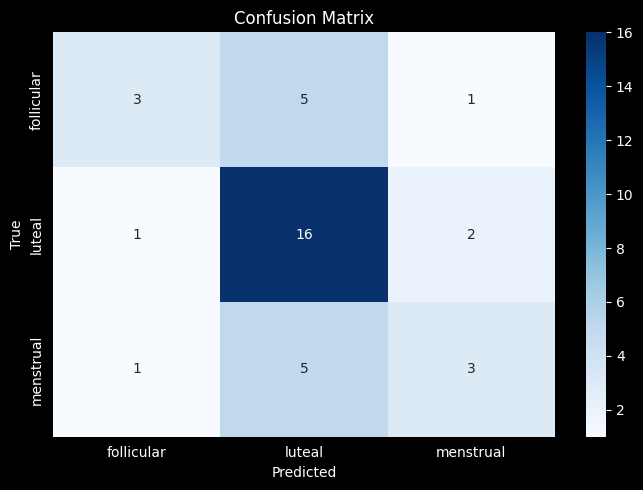

In [11]:
# 1) Confusion Matrix (Seaborn)
labels = np.unique(np.concatenate([np.array(y_test), np.array(y_pred)]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

if BINARY_LUTEAL_TEST:
    tick_labels = [target_label_names[int(l)] for l in labels]
else:
    tick_labels = labels

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()


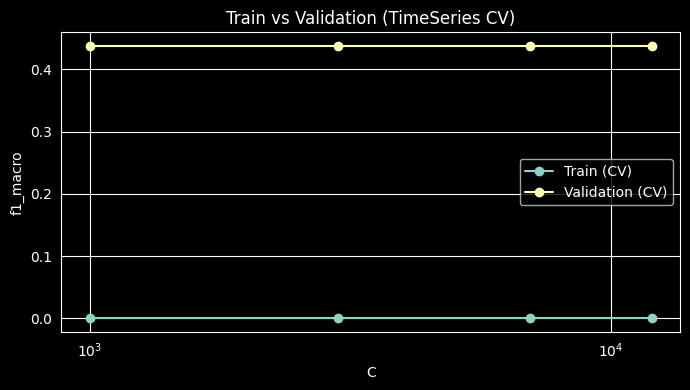

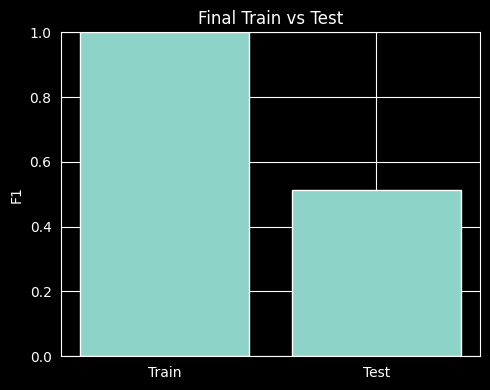

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score

# 1) Train/Validation curve from GridSearchCV
# cv_df = pd.DataFrame(grid.cv_results_).sort_values("param_clf__C")
cv_df = pd.DataFrame(grid.cv_results_).copy()
best_C = grid.best_params_["clf__C"]
best_tol = grid.best_params_["clf__tol"]

sub = cv_df[
    (cv_df["param_clf__C"] == best_C) &
    (cv_df["param_clf__tol"] == best_tol)
].sort_values("param_clf__max_iter")

plt.figure(figsize=(7,4))
plt.plot(sub["param_clf__max_iter"], 1 - sub["mean_train_score"], marker="o", label="Train (CV)")
plt.plot(sub["param_clf__max_iter"], 1 - sub["mean_test_score"], marker="o", label="Validation (CV)")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel(f"{scoring_metric}")
plt.title("Train vs Validation (TimeSeries CV)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Final Train vs Test
y_train_pred = best.predict(X_train)
y_test_pred = best.predict(X_test)

if scoring_metric == "f1":
    train_score = f1_score(y_train, y_train_pred)
    test_score = f1_score(y_test, y_test_pred)
else:
    train_score = f1_score(y_train, y_train_pred, average="macro")
    test_score = f1_score(y_test, y_test_pred, average="macro")

plt.figure(figsize=(5,4))
plt.bar(["Train", "Test"], [train_score, test_score])
plt.ylim(0, 1)
plt.ylabel("F1")
plt.title("Final Train vs Test")
plt.tight_layout()
plt.show()